---
title: Transmission of Hop Powdery Mildew (*Podosphaera macularis*) in the Willamette Valley
subtitle: CS 546 Final Project -- Networks in Computational Biology
authors: 
    - Tobias Kohn
    - Trent VanHawkins
    
format:
  html:
    code-fold: true
---

### Introduction

Pathogens displaying Long-Distance Dispersal (LDD) pose a substantial threat to global food security and agronomics. Existing agricultural managemenet practices often include treatments such as fungicide, herbicide, or pesticide; however,  airborne pathogens can readily invade across abritrary jurisdictional boundaries and propogate new infections where management practices differ. Anually, these diseases pose an estimated $220 Billion in harvest loss [@chakr]. The Willamette Valley in particular is a global leader in the production of Hops (*Humulus lupulus*) and Powdery Mildew (*Podosphaera macularis*) is a regionally important diesease which can lead to total crop loss if not managed appropriately [CITE]. The disease appeared in the Willamette Valley for the first time in 1998, and has occured in every subsequent year up until the present. As such, the hop powdery mildew pathosystem has become one of particular concern for growers and managers within the region.

Models of disease spread are a classical focus of pathology research. In recent years, however, these classical, mechanistic models have been placed into the context of spatially explicit networks, which use stochastic methods to learn network structures across discrete time transitions [CITE]. Letting $t$ denote time, we define a *discrete time transition* as the transiton from the disease state at $t - 1$ to time $t$. Then, we can treat classical models of auto-infection--how much disease spread at a particular unit is due to its previous infection locally-- and dispersal--how much disease is due to infection from other sourcses-- as covariate kernels in a likelihood based framework. Thus, conditioning on the disease state at $t-1$, we can try to learn the parameters associated with each kernel to predict the disease state at time $t$.

From 2014 to 2017, Hop growers in the Willamette Valley partook in an annual sentinal monitoring program for powdery mildew. Farms were surveyed monthly for the number of infected plants in each yard, the experimenatl unit, from May to July. In the present study, we aim to recreate the network structure from these disease data using the framework proposed by  and [CITE]. An interesting feature of the proposed method is that the resulting adjasency matrix must account for the restriction illustrated by Figure 1. 

!["Figure 1: A simple graph denoting constraints of disease spread within the resulting network."](figures/strain_contraints.png)

Briefly, each yard can grow one hop cultivar in each season -- R6 or non-R6. R6 cultivars have been genetically modified for resistance against hop powdery mildew. As often occurs, though, a strain of the disease has mutated to overcome the R6 resistance. This mutated strain is termed a "V6" pathogen, thus the disease strain can be "V6" or "non-V6". The initial disease strain was sampled at each yard at first detection each season, allowing for three different possibilities: an R6 yard with initial strain V6, a non-R6 yard with initial strain V6, or a non-R6 yard with initial strain non-V6. The case of V6 yards with initial strain non-V6 are not considered biologically meaningful (the presence of spores does not imply disease spread) and are ommitted for clarity. The restriction on our network is as follows: **non-R6 yards may only infect R6 yards if they have initial strain V6**. We elaborate on how this restriction is imposed in the methods section below. 

Clearly, this constrained, directed, and weighted adjacency matrix proposes a compelling opportunity to explore some of the analysis tools we have discussed in CS 546. In the present study, we propose to investigate the feasability and behavior of some basic tools of netowrk analysis including vertex-degree, and basic measures of vertex centrality. We then use these measures to create a descriptive profile of important yards for disease transimission within the Willamette Valley. 

### Methods

#### The Data
Biological data were obtained from a sentinel monitoring program in which hop yards representative of the Willamette Valley production region were surveyed monthly from April to July across the 2014–2017 growing seasons. Disease assessments recorded the incidence of plants with powdery mildew or primary infection (flag shoots) across 8–10 farms per year, all within Marion County, Oregon. Following data cleaning, usable records were available for 99, 113, 116, and 122 yards in 2014, 2015, 2016, and 2017, respectively. Full details of the sampling and assessment methodology are provided in [CITE]

At first detection of powdery mildew in a given yard each season, the infecting strain was characterized as either V6-virulent or non-V6-virulent via bioassay. This distinction is critical because P. macularis strains differ in their ability to cause disease on hop cultivars carrying the R6 resistance gene: non-V6-virulent strains cannot infect R6 cultivars, while V6-virulent strains can infect both R6 and non-R6 cultivars. This strain classification directly informs the network constraints described in the Introduction and elaborated upon in the Methods below.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  149k  100  149k    0     0      0      0 --:--:-- --:--:-- --:--:--     0    0     0   478k      0 --:--:-- --:--:-- --:--:--  480k


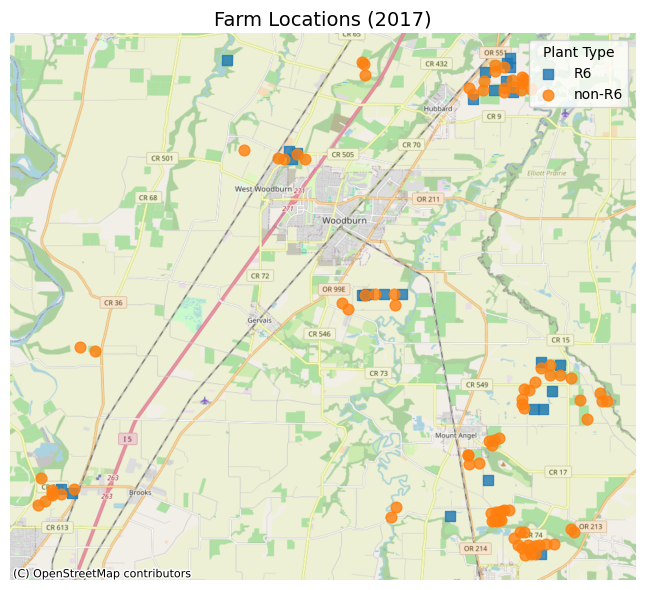

In [162]:
#| label: fig-farm-locations
#| fig-cap: "Farm locations in 2017, colored by plant type."

import scipy
import cairo
import igraph as ig
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from typing import Any

pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

#Read in the metadata
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/data/processed/clean_summary.csv -o clean_summary.csv
meta = pd.read_csv('clean_summary.csv', index_col=0, header=0)

! rm clean_summary.csv
meta["date"] = pd.to_datetime(meta["date"])

# Filter to 2017, one row per farm (drop duplicate locations)
meta_2017 = meta[meta["year"] == 2017].drop_duplicates(subset="field_id").reset_index(drop=True)

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    meta_2017,
    geometry=[Point(xy) for xy in zip(meta_2017["centroid_long"], meta_2017["centroid_lat"])],
    crs="EPSG:4326"
).to_crs(epsg=3857)  # reproject for contextily basemap

# Marker shapes per plant type
markers = {pt: m for pt, m in zip(gdf["plant_type"].unique(), ["o", "s", "^", "D", "v"])}

fig, ax = plt.subplots(figsize=(8, 6))

for plant_type, group in gdf.groupby("plant_type"):
    group.plot(
        ax=ax,
        marker=markers[plant_type],
        markersize=60,
        label=plant_type,
        alpha=0.8
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Farm Locations (2017)", fontsize=14)
ax.legend(title="Plant Type", loc="upper right")
ax.set_axis_off()

plt.tight_layout()
plt.show()

#### Constructing the adjacency matrix
Letting $y_{i,t}$ denote the number of diseased plants at yard $i$ and time $t$, we assume that $y_{i, t}, \ldots, y_{n, t}$ are conditionally independent Binomial random variables with parameters $M$ for the number of plants sampled at yard $i$ and $p$ for the probability of a given plant having the disease. We can then model $p_t$ using a non-linear geralized regression model with a logit link as 

$$
\log\left(\frac{p_{i,t}}{1-p_{i,t}}\right) = \beta + \delta\underbrace{\left(\frac{\tilde{y}_i}{n_{\tilde{y}_i}}e^{-\eta_1 s_i}\right)}_{\text{auto-infection}} + \gamma \underbrace{\sum_{j \neq i} \left(\frac{a_j z_j}{n_{z_j}} e^{-\eta_2 s_j} w_{ij} (1 + d_{ij})^{-\alpha} \right)}_{\text{cross-infection}}
$$

where covariates are interpreted as in @tbl-covariates and parameters as in @tbl-parameters. Maximum Likelihood Estimates (MLEs) were obtained for each of the parameters using numerical approximation methods as described in [CITE]. To allow for the restriction proposed previously, parameters were estimated separately for R6 and non-R6 yards. 


: Covariate notations and descriptions. {#tbl-covariates}

| Covariate | Description |
|-----------|-------------|
| $\tilde{y}_i$ | Number of diseased plants at yard $i$ in the prior month |
| $n_{\tilde{y}_i}$ | Number of plants sampled at yard $i$ in the prior month |
| $a_i$ | Area (hectares) of yard $i$ |
| $z_j$ | Number of diseased plants at yard $j$ in the prior month |
| $n_{z_j}$ | Number of plants sampled at yard $j$ in the prior month |
| $a_j$ | Area (hectares) of yard $j$ |
| $D_{ij}$ | Distance (kilometers) from centroids of yard $i$ to yard $j$ |
| $w_{ij}$ | Wind vector on $j - i$ direction in the prior month |
| $s_i$ | Number of fungicide sprays in yard $i$ in prior month |
| $t_j$ | Number of fungicide sprays in yard $j$ in prior month |

: Model parameters and descriptions. {#tbl-parameters}

| Parameter | Description |
|-----------|-------------|
| $\beta$ | Baseline log-odds of disease, after accounting for autoinfection and dispersal. |
| $\delta$ | Change in log-odds of disease associated with autoinfection at the yard scale, after accounting for disease spread. |
| $\gamma$ | Distance-adjusted change in log-odds of disease associated with disease spread from other yards, after accounting for autoinfection. |
| $\alpha$ | Dispersal parameter providing distance adjustment to change in log-odds of disease associated with individual source yards. |
| $\eta_1$ | Change in log-odds of disease associated with autoinfection at the yard scale, after accounting for fungicide sprays. |
| $\eta_2$ | Dispersal parameter providing fungicide spray adjustment to change in log-odds of disease associated with individual source yards. |

*Descriptions of model parameters and covariates notations for each yard of interest $i = 1,2,...,N$ in a month, and all other yards $j = 1,2,...,M_i$ relative to yard $i$.*

Once the MLEs are obtained, the weighted edge from source yard $j$ to target yard $i$ is obtained as 

$$
A_{ij} = \begin{cases} 
\gamma_1 \frac{a_j z_j}{n_{z_j}} e^{-\eta_{21} s_j} w_{ji} (1 + D_{ij})^{-\alpha_1} \cdot \mathbb{1}_{V6}(j) & \text{Yard $i$ is R6} \\
\gamma_2 \frac{a_j z_j}{n_{z_j}} e^{-\eta_{22} s_j} w_{ji} (1 + D_{ij})^{-\alpha_2} & \text{Yard $i$ is non-R6}
\end{cases}
$$

That is, the edge-weight depends on both the plant type (R6 or non-R6) of yard $i$ and the initial strain (V6 or non-V6) at yard $j$ as depicted in Figure 1. 

#### Analysis of Yard Importance

Once we obtained the adjacency matrix $A$, we computed the out-degree and out-going 
Katz centrality for each yard. Considering that $a_{ij}$ denotes the edge weight 
for disease transmission from yard $j$ to yard $i$, we computed in- and out-degree, 
respectively, as:

$$
k_i^{(\text{in})} = \sum_j a_{ij} \quad \text{and} \quad k_j^{(\text{out})} = \sum_i a_{ij}
$$

We then examined the degree distribution for both in- and out-degree to test whether 
it follows a power law above some threshold $k_{\min}$. Specifically, we tested whether 
the probability mass function takes the form:

$$
p(k) = \frac{\hat{\tau} - 1}{k_{\min}}\left(\frac{k}{k_{\min}}\right)^{-\hat{\tau}}, \quad k \geq k_{\min}
$$

where $\hat{\tau}$ is the MLE of the scaling exponent and $k_{\min}$ is estimated via 
KS-statistic minimization following [CITE] as implemented in the `power_law_fit` method in `iGraph` and assess the goodness-of-fit using its inherint bootstrap approach. 

In addition to in- and out-degree for each yard, we compute the **Katz centrality** for each yard. We specifically chose Katz centrality as it assigns a baseline centrality to all nodes regardless of connectivity -- a desirable property in a sparse disease network. Katz centrality for yard $i$ is defined as

$$
\mathbf{x} = \rho \mathbf{A}\mathbf{x} + \mathbf{1} \implies \mathbf{x} = (\mathbf{I} - \rho \mathbf{A})^{-1} \cdot \mathbf{1}
$$

The free parameter $\rho$ controls the contribution of the eigenvector, and is subject to the constraint that $\rho < \kappa_1^{-1}$ where $\kappa_1$ is the spectral radius of $\mathbf{A}$. We adopt the convention of PageRank centrality and set $\rho = \frac{0.85}{\kappa_1}$. As we are most interested in the yards that are important for *spreading* disease, we compute Katz centrality for outgoing edges only. We present ranked Katz centrality for each month in visual and tabular formats.



### Results

In [160]:
# Read in the adjacency matrices from the CSV files
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_apr_may.csv -o network_apr_may.csv
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_may_jun.csv -o network_may_jun.csv
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_jun_jul.csv -o network_jun_jul.csv
apr_may = pd.read_csv('network_apr_may.csv', index_col=0, header=0)
may_jun = pd.read_csv('network_may_jun.csv', index_col=0, header=0)
jun_jul = pd.read_csv('network_jun_jul.csv', index_col=0, header=0)

#Read in the metadata
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/data/processed/clean_summary.csv -o clean_summary.csv
meta = pd.read_csv('clean_summary.csv', index_col=0, header=0)

! rm clean_summary.csv
! rm network_apr_may.csv
! rm network_may_jun.csv
! rm network_jun_jul.csv

meta["date"] = pd.to_datetime(meta["date"])
# Filter to 2017, one row per farm (drop duplicate locations)
meta_2017 = meta[meta["year"] == 2017].drop_duplicates(subset="field_id").reset_index(drop=True)

#Write a function to build an igraph with metadata
def build_graph(adj_df, meta_df):
    # Build graph
    g = ig.Graph.Weighted_Adjacency(adj_df.to_numpy().transpose(), mode="directed", attr="weight", loops=False)
    
    # Add node names
    g.vs["name"] = adj_df.columns.tolist()
    
    # Add metadata attributes
    meta_indexed = meta_df.set_index("field_id")
    for col in meta_indexed.columns:
        g.vs[col] = [meta_indexed.loc[int(v["name"]), col] for v in g.vs]
    
    return g

apr_may_g: ig.Graph = build_graph(apr_may, meta_2017)
may_jun_g: ig.Graph= build_graph(may_jun, meta_2017)
jun_jul_g: ig.Graph= build_graph(jun_jul, meta_2017)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 67020  100 67020    0     0   299k      0 --:--:-- --:--:-- --:--:--  300k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 73431  100 73431    0     0   281k      0 --:--:-- --:--:-- --:--:--  281k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  104k  100  104k    0     0   389k      0 --:--:-- --:--:-- --:--:--  390k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  149k  100  149k    0     0   868k      0 --:--:-- --:--:-- --:--:--  868k



#### Network Structure
- Brief table summarizing the three time windows (apr_may, may_jun, jun_jul) side by side: number of nodes, edges, density, and mean in/out-degree
- One paragraph briefly interpreting results

In [28]:
non_R6 = meta_2017[meta_2017["plant_type"] == "non-R6"]["field_id"]
R6 = meta_2017[meta_2017["plant_type"] == "R6"]["field_id"]
non_V6 = meta_2017[meta_2017["initial_strain"] == "non-V6"]["field_id"]
V6 = meta_2017[meta_2017["initial_strain"] == "V6"]["field_id"]

labels = jun_jul.index

# Compute out-strength (weighted out-degree) for each graph
out_apr_may = np.array(apr_may_g.strength(mode = "out", weights="weight"))
out_may_jun = np.array(may_jun_g.strength(mode = "out", weights="weight"))
out_jun_jul = np.array(jun_jul_g.strength(mode = "out", weights="weight"))

in_apr_may = np.array(apr_may_g.strength(mode = "in", weights="weight"))
in_may_jun = np.array(may_jun_g.strength(mode = "in", weights="weight"))
in_jun_jul = np.array(jun_jul_g.strength(mode = "in", weights="weight"))



#### Strength Distribution
- One figure with 6 panels (in- and out-degree $\times$ three time windows) on log-log scale
- Table reporting $\hat{\tau}$ and $\hat{k}_{\min}$ and GoF p-value for each panel
- Note sparsity caveat for out-degree 


In [163]:
def strength_distribution(graph: ig.Graph, name: str = "", bins = 20) -> list[dict[str, Any]]:

  in_d = np.array(graph.strength(mode = "in", weights="weight"))
  out_d = np.array(graph.strength(mode = "out", weights="weight"))
  ret = []
  to_plot = []
  modes = ["in", "out"]

  for mode, strength in enumerate([in_d, out_d]):
    m = modes[mode]
    strength = strength[strength > 0]
    y, edges = np.histogram(strength, bins=bins)
    x = 0.5 * (edges[:-1] + edges[1:])
    i = y > 0

    result = ig.statistics.power_law_fit(strength)
    ret.append({"name": f"{name}_{m}", "alpha": result.alpha, "k_min": result.xmin, "p_value": result.p, "x": x[i], "y": y[i]})
    
 
  else:
    plt.close(fig)

  return ret

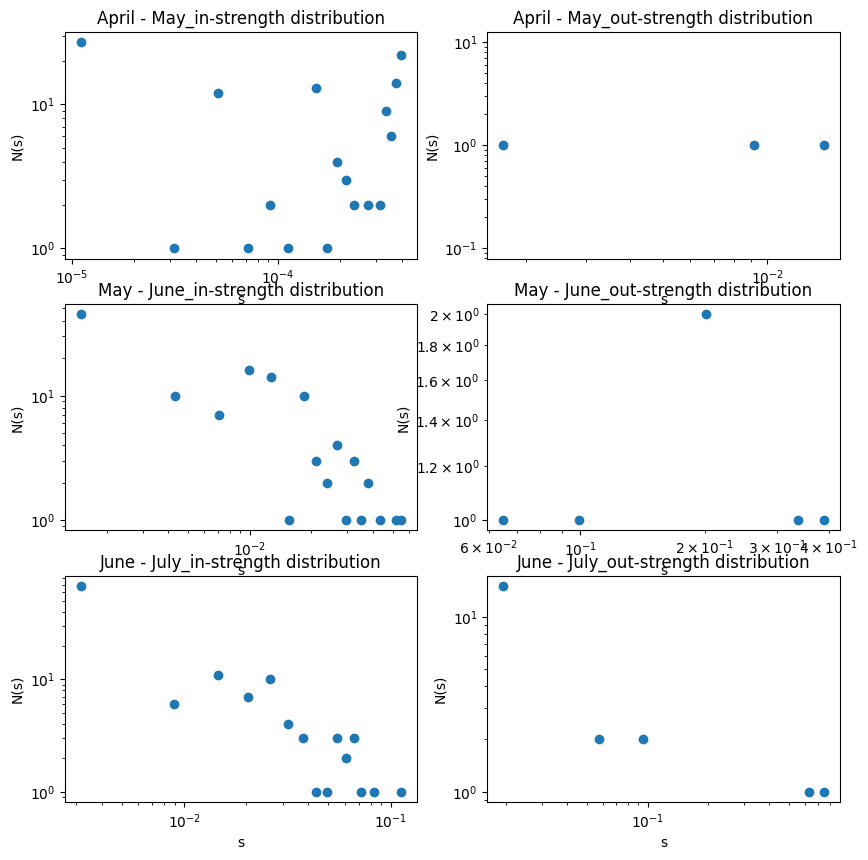

,name,alpha,k_min,p_value
0,April - May_in,49.711904,0.000389,0.2440
1,April - May_out,3.099033,0.009252,0.1944
2,May - June_in,2.467547,0.008379,0.0056
3,May - June_out,3.470326,0.201261,0.1036
4,June - July_in,2.841434,0.022836,0.0504
5,June - July_out,1.544592,0.004065,0.3584


In [172]:
deg_disributions = []
to_plot = []
graphs = [apr_may_g, may_jun_g, jun_jul_g]
names = ["April - May", "May - June", "June - July"]
for graph, name in zip(graphs, names):

    deg_disributions += strength_distribution(graph, name=name)

n = len(deg_disributions)
deg_disributions_df = pd.DataFrame(deg_disributions)

fig, axs = plt.subplots(n // 2, 2, figsize=(10, 10))
axs = axs.flatten()
for ax, (_, row) in zip(axs, deg_disributions_df.iterrows()):
    ax.loglog(row["x"], row["y"], "o")
    ax.set_xlabel("s")
    ax.set_ylabel("N(s)")
    ax.set_title(f'{row["name"]}-strength distribution')
plt.show()
deg_disributions_df[["name", "alpha", "k_min", "p_value"]].head(n)


#### Yard Importance
- Single table showing top $N$ yards by outgoing Katz centrality across all three time windows side by side
- Figure showing full ranked Katz score distribution (ranked bar chart) for each time window


In [177]:
def spectral_radius(adj_matrix: np.ndarray):
    #Get eigenvalues
    eigenvalues = np.linalg.eigvals(adj_matrix)
    #return the maximum absolute value
    return np.max(np.abs(eigenvalues))

def katz_centrality(adj_matrix: np.ndarray, alpha: float, out = True):
    #Number of nodes
    n = adj_matrix.shape[0]
    
    #Identity matrix of appropriate size
    I = np.eye(n)
    
    #Transpose if calculating out-centrality
    if out:
        adj_matrix = adj_matrix.T
    
    #Compute Katz centrality using the formula: (I - alpha * A^T)^(-1) - 1 (-1 to recenter)
    centrality = np.linalg.solve(I - alpha * adj_matrix, np.ones(n)) - 1
    
    return centrality

In [176]:
a = 0.9 / spectral_radius(jun_jul)
katz_out = pd.DataFrame(katz_centrality(jun_jul, a), columns=["katz"], index=labels).sort_values("katz", ascending=False)
katz_in = pd.DataFrame(katz_centrality(jun_jul, a, out=False), columns=["katz"], index=labels).sort_values("katz", ascending=False)

katz_in = katz_in.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_in["group"] = katz_in["initial_strain"] + " | " + katz_in["plant_type"]

katz_out = katz_out.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_out["group"] = katz_out["initial_strain"] + " | " + katz_out["plant_type"]

In [174]:
katz_out.head()

,field_id,katz,initial_strain,plant_type,group
0,22,286.911672,V6,non-R6,V6 | non-R6
1,63,172.353058,V6,non-R6,V6 | non-R6
2,31,79.117358,V6,R6,V6 | R6
3,25,61.584614,V6,non-R6,V6 | non-R6
4,33,45.432341,V6,non-R6,V6 | non-R6


In [175]:
katz_in.head()

,field_id,katz,initial_strain,plant_type,group
0,30,53.193036,V6,R6,V6 | R6
1,27,30.303936,V6,R6,V6 | R6
2,28,26.200527,non-V6,R6,non-V6 | R6
3,26,24.718350,non-V6,R6,non-V6 | R6
4,136,22.933740,V6,R6,V6 | R6


<Axes: title={'center': 'katz'}, xlabel='group'>

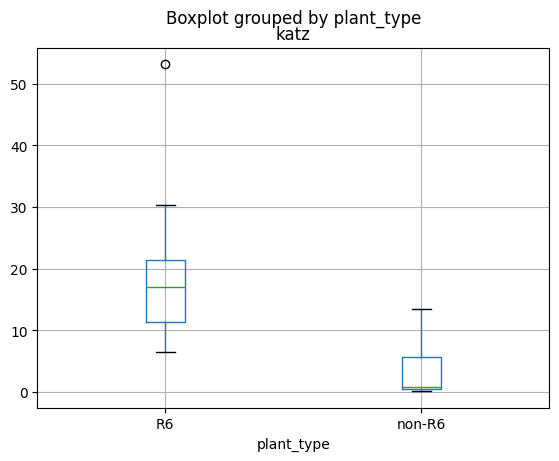

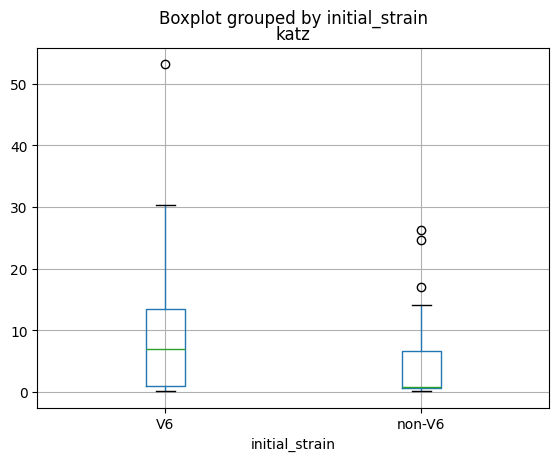

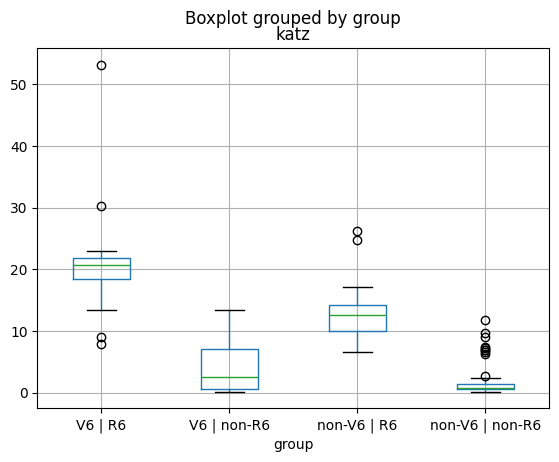

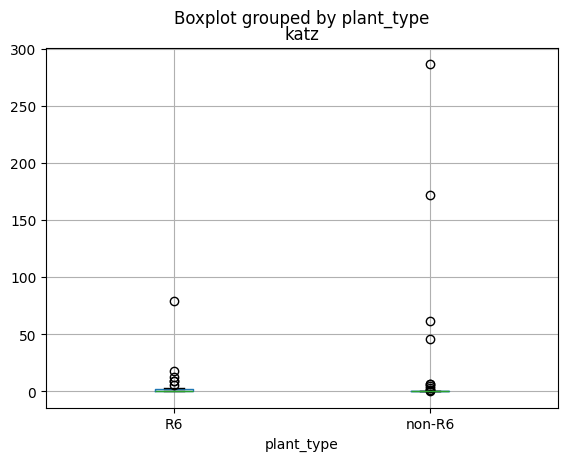

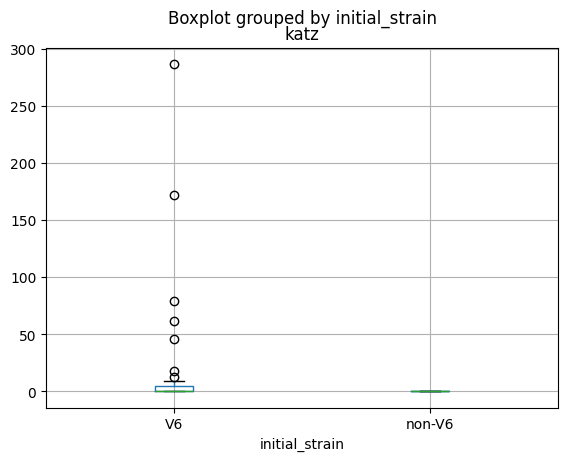

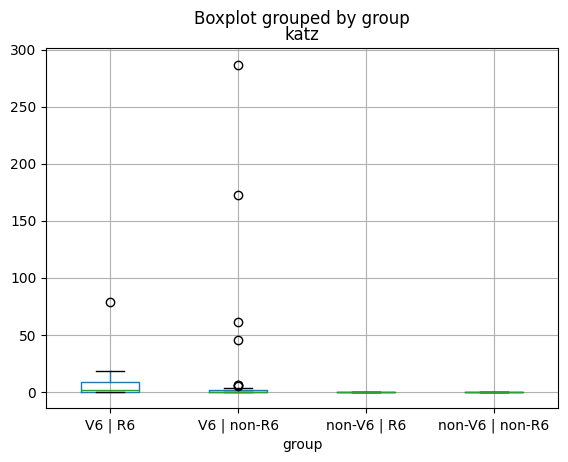

In [157]:
katz_in.boxplot(column="katz", by="plant_type")
katz_in.boxplot(column="katz", by="initial_strain")
katz_in.boxplot(column="katz", by="group")

katz_out.boxplot(column="katz", by="plant_type")
katz_out.boxplot(column="katz", by="initial_strain")
katz_out.boxplot(column="katz", by="group")


#### Concentration of Transmission
- what fraction of yards account for 70 or 80% of total out-degree/centrality


### Discussion
#### General summary of conclusions
#### Limitations
#### Future directions